# Model Training - ResNet50 Transfer Learning

Fine-tune ResNet50 pretrained on ImageNet for the Oxford 102 Flower Dataset.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [3]:
# Load datasets
checkpoint = torch.load(
    '../data/processed_datasets.pth',
    map_location='cpu',
    weights_only=False
)
train_dataset = checkpoint['train_dataset']
val_dataset = checkpoint['val_dataset']
test_dataset = checkpoint['test_dataset']

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

In [4]:
# Load pretrained ResNet50 and modify final layer
def create_resnet50_model(num_classes=102, freeze_features=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    # Freeze all layers initially
    if freeze_features:
        for param in model.parameters():
            param.requires_grad = False
    
    # Replace final fully connected layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

model = create_resnet50_model(num_classes=102, freeze_features=True)
model = model.to(device)

print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%



Total parameters: 23,717,030
Trainable parameters: 208,998


In [5]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [6]:
# Reuse training functions from VGG16 notebook
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

In [7]:
# Training loop
num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    start_time = time.time()
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
          f"Time: {time.time()-start_time:.2f}s")

Epoch 1/10 - Train Loss: 4.7443, Train Acc: 0.0451, Val Loss: 3.7265, Val Acc: 0.2167, Time: 695.74s
Epoch 2/10 - Train Loss: 3.1928, Train Acc: 0.4039, Val Loss: 2.8146, Val Acc: 0.4529, Time: 829.90s
Epoch 3/10 - Train Loss: 2.3205, Train Acc: 0.5941, Val Loss: 2.1852, Val Acc: 0.5637, Time: 881.38s
Epoch 4/10 - Train Loss: 1.7432, Train Acc: 0.6980, Val Loss: 1.8649, Val Acc: 0.6235, Time: 1064.54s
Epoch 5/10 - Train Loss: 1.3585, Train Acc: 0.7686, Val Loss: 1.6039, Val Acc: 0.6706, Time: 601.06s
Epoch 6/10 - Train Loss: 1.1132, Train Acc: 0.8539, Val Loss: 1.4016, Val Acc: 0.7539, Time: 723.43s
Epoch 7/10 - Train Loss: 1.0041, Train Acc: 0.8951, Val Loss: 1.3435, Val Acc: 0.7716, Time: 561.18s
Epoch 8/10 - Train Loss: 0.9659, Train Acc: 0.9147, Val Loss: 1.3365, Val Acc: 0.7765, Time: 501.42s
Epoch 9/10 - Train Loss: 0.9309, Train Acc: 0.9235, Val Loss: 1.3162, Val Acc: 0.7765, Time: 640.02s
Epoch 10/10 - Train Loss: 0.9325, Train Acc: 0.9216, Val Loss: 1.3059, Val Acc: 0.7804, Ti

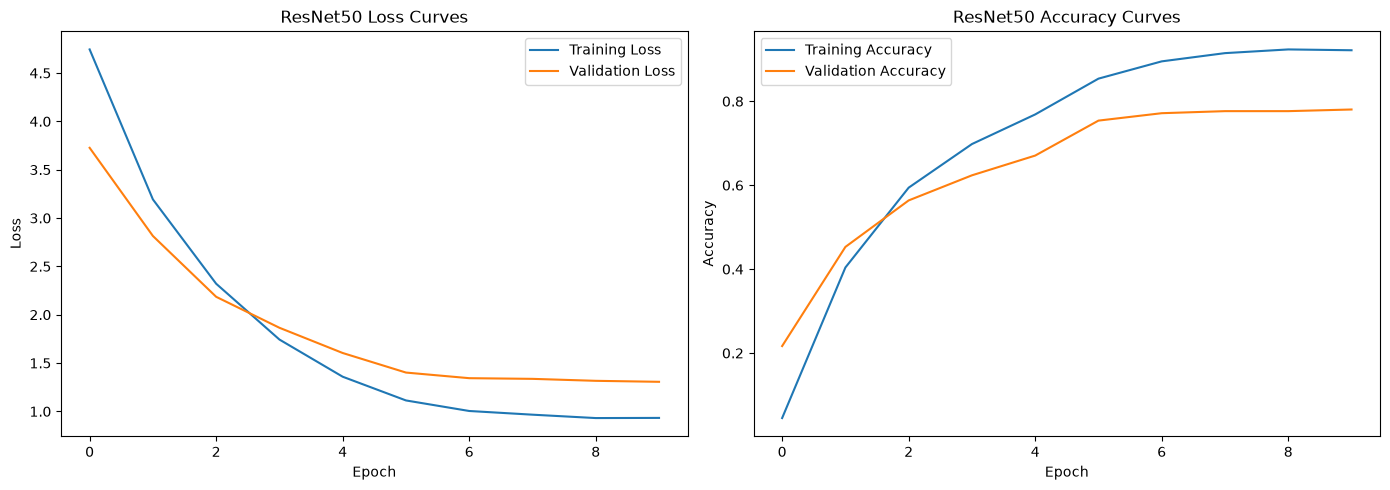

In [8]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('ResNet50 Loss Curves')
ax1.legend()

ax2.plot(train_accs, label='Training Accuracy')
ax2.plot(val_accs, label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('ResNet50 Accuracy Curves')
ax2.legend()

plt.tight_layout()
plt.show()

In [9]:
# Save model
torch.save(model.state_dict(), '../models/resnet50_flowers102.pth')
print("ResNet50 model saved successfully!")

ResNet50 model saved successfully!
